# Contour(輪郭)／blob(塊) 分析 

## 1. 画像の読み込み

binarized_image.shape=(400, 400)


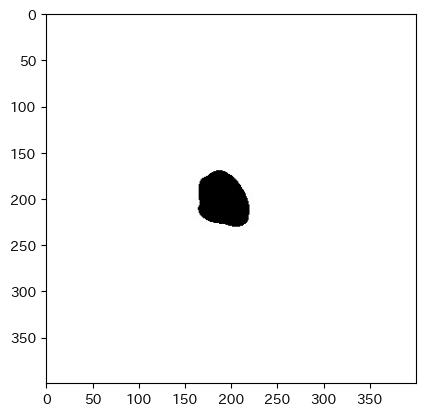

In [1]:
import cv2
import matplotlib.pyplot as plt

binarized_image = cv2.imread('data/single_dot_binarized_image01.jpg', cv2.IMREAD_GRAYSCALE)  # グレースケールで読み込む
print(f"{binarized_image.shape=}")
plt.imshow(binarized_image, cmap='gray')

## 2. 輪郭分析

cv2.findContours<br>
https://docs.opencv.org/4.x/d3/dc0/group__imgproc__shape.html#gae4156f04053c44f886e387cff0ef6e08

【Python・OpenCV】輪郭を検出するには(cv2.findContours)<br>
https://www.codevace.com/py-opencv-findcontours/

In [2]:
import cv2
contours, hierarchy = cv2.findContours(image=binarized_image, mode=cv2.RETR_TREE, method=cv2.CHAIN_APPROX_NONE)

In [3]:
print(f"{type(contours)=}")
print(f"{len(contours)=}")
contours

type(contours)=<class 'tuple'>
len(contours)=42


(array([[[0, 0]],
 
        [[0, 1]],
 
        [[0, 2]],
 
        ...,
 
        [[3, 0]],
 
        [[2, 0]],
 
        [[1, 0]]], shape=(1596, 1, 2), dtype=int32),
 array([[[205, 229]],
 
        [[206, 228]],
 
        [[207, 229]],
 
        [[207, 230]],
 
        [[206, 231]],
 
        [[205, 231]],
 
        [[204, 230]]], dtype=int32),
 array([[[196, 229]],
 
        [[197, 228]],
 
        [[198, 229]],
 
        [[197, 230]]], dtype=int32),
 array([[[210, 225]],
 
        [[211, 224]],
 
        [[212, 224]],
 
        [[213, 225]],
 
        [[213, 226]],
 
        [[212, 227]],
 
        [[213, 226]],
 
        [[214, 226]],
 
        [[215, 227]],
 
        [[214, 228]],
 
        [[213, 229]],
 
        [[212, 229]],
 
        [[211, 229]],
 
        [[210, 230]],
 
        [[209, 229]],
 
        [[209, 228]],
 
        [[210, 227]],
 
        [[209, 226]]], dtype=int32),
 array([[[208, 225]],
 
        [[209, 224]],
 
        [[210, 225]],
 
        [[209, 226]]], dt

In [4]:
print(f"{type(hierarchy)=}")
print(f"{hierarchy.shape=}")
hierarchy

type(hierarchy)=<class 'numpy.ndarray'>
hierarchy.shape=(1, 42, 4)


array([[[-1, -1,  1, -1],
        [ 2, -1, -1,  0],
        [ 3,  1, -1,  0],
        [ 4,  2, -1,  0],
        [ 5,  3, -1,  0],
        [ 6,  4, -1,  0],
        [ 7,  5, -1,  0],
        [ 8,  6, -1,  0],
        [ 9,  7, -1,  0],
        [10,  8, -1,  0],
        [11,  9, -1,  0],
        [12, 10, -1,  0],
        [13, 11, -1,  0],
        [14, 12, -1,  0],
        [15, 13, -1,  0],
        [17, 14, 16,  0],
        [-1, -1, -1, 15],
        [18, 15, -1,  0],
        [19, 17, -1,  0],
        [20, 18, -1,  0],
        [21, 19, -1,  0],
        [22, 20, -1,  0],
        [23, 21, -1,  0],
        [24, 22, -1,  0],
        [25, 23, -1,  0],
        [41, 24, 26,  0],
        [27, -1, -1, 25],
        [28, 26, -1, 25],
        [29, 27, -1, 25],
        [30, 28, -1, 25],
        [31, 29, -1, 25],
        [32, 30, -1, 25],
        [33, 31, -1, 25],
        [34, 32, -1, 25],
        [35, 33, -1, 25],
        [36, 34, -1, 25],
        [37, 35, -1, 25],
        [38, 36, -1, 25],
        [39,

In [5]:
# 輪郭の面積を計算する
import cv2
contour_areas = [cv2.contourArea(contour) for contour in contours]
contour_areas

[159201.0,
 5.5,
 2.0,
 21.0,
 2.0,
 4.0,
 2.0,
 4.0,
 12.5,
 2.0,
 2.0,
 2.0,
 2.0,
 4.0,
 2.0,
 25.5,
 0.0,
 2.0,
 2.0,
 2.0,
 2.0,
 11.0,
 2.0,
 2.0,
 8.5,
 2495.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 35.5]

In [6]:
# 輪郭面積のヒストグラムを描画する (plotly)
import plotly.graph_objects as go
fig = go.Figure(data=[go.Histogram(x=contour_areas, nbinsx=20)])
fig.update_layout(title='Contour Area Distribution', xaxis_title='Area', yaxis_title='Count')
fig.show()


In [7]:
# 輪郭面積により輪郭をフィルタリングする
import cv2
filtered_contours = [contour for contour in contours if 1000 < cv2.contourArea(contour) < 10000]  # 面積が1000以上10000未満の輪郭を残す

filtered_contour_areas = [cv2.contourArea(contour) for contour in filtered_contours]
import plotly.graph_objects as go
fig = go.Figure(data=[go.Histogram(x=filtered_contour_areas, nbinsx=20)])
fig.update_layout(title='Filtered Contour Area Distribution', xaxis_title='Area', yaxis_title='Count')
fig.show()

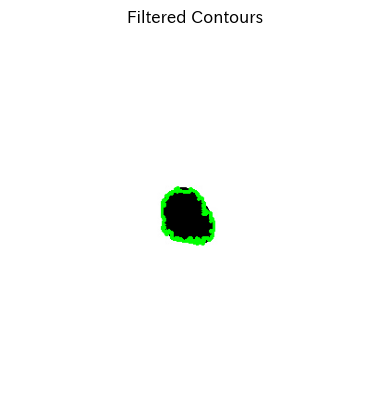

In [8]:
# 領域の描画
import cv2
import matplotlib.pyplot as plt
# 元の画像をカラーで読み込む
original_image = cv2.imread('data/single_dot_binarized_image01.jpg')
# 輪郭を描画するためにコピーを作成
image_with_contours = original_image.copy()
# 輪郭を描画
cv2.drawContours(image_with_contours, filtered_contours, -1, (0, 255, 0), 2)
# 画像を表示
plt.imshow(cv2.cvtColor(image_with_contours, cv2.COLOR_BGR2RGB))
plt.title('Filtered Contours')
plt.axis('off')
plt.show()

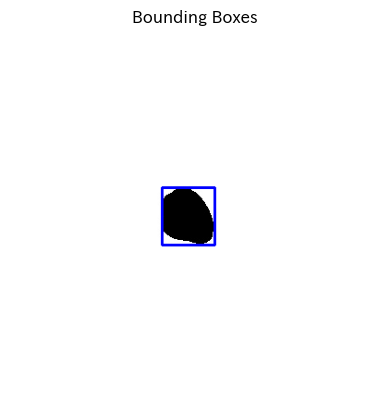

In [9]:
# 領域を囲む四角形
import cv2
bounding_boxes = [cv2.boundingRect(contour) for contour in filtered_contours]
# 四角形を描画するためにコピーを作成
image_with_boxes = original_image.copy()
# 四角形を描画
for (x, y, w, h) in bounding_boxes:
    cv2.rectangle(image_with_boxes, (x, y), (x + w, y + h), (255, 0, 0), 2)
# 画像を表示
plt.imshow(cv2.cvtColor(image_with_boxes, cv2.COLOR_BGR2RGB))
plt.title('Bounding Boxes')
plt.axis('off')
plt.show()

## 3. 塊分析

OpenCV Structural Analysis and Shape Descriptors<br>
https://docs.opencv.org/3.4/d3/dc0/group__imgproc__shape.html

OpenCV connectedComponentsWithStats<br>
https://docs.opencv.org/3.4/d3/dc0/group__imgproc__shape.html#ga107a78bf7cd25dec05fb4dfc5c9e765f

【OpenCV-Python】ラベリング (connectedComponents)<br>
https://imagingsolution.net/program/python/opencv-python/connectedcomponents/

In [10]:
# ブロブ分析
import cv2

# ラベリング画像と、ブロブの領域（位置、幅、高さ）と面積、重心の情報を出力
retval, labeled_image, stats, centroids = cv2.connectedComponentsWithStats(binarized_image, connectivity=8)

print(f"{type(retval)=}")
print(f"{retval=}")

print(f"{type(labeled_image)=}")
print(f"{labeled_image.shape=}")

print(f"{type(stats)=}")
print(f"{stats.shape=}")

print(f"{type(centroids)=}")
print(f"{centroids.shape=}")

type(retval)=<class 'int'>
retval=18
type(labeled_image)=<class 'numpy.ndarray'>
labeled_image.shape=(400, 400)
type(stats)=<class 'numpy.ndarray'>
stats.shape=(18, 5)
type(centroids)=<class 'numpy.ndarray'>
centroids.shape=(18, 2)


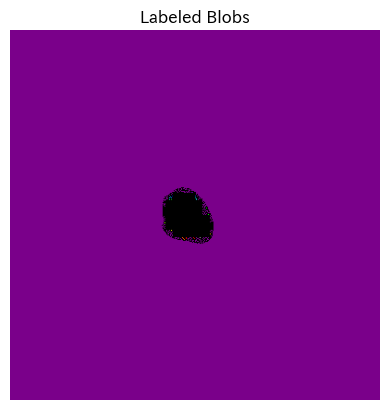

In [11]:
import cv2
plt.imshow(labeled_image, cmap='nipy_spectral')
plt.title('Labeled Blobs')
plt.axis('off')
plt.show()

In [12]:
# 各ラベル毎の領域の情報 [左上X座標, 左上Y座標, 幅, 高さ, 面積]
stats

array([[   164,    170,     56,     61,   2391],
       [     0,      0,    400,    400, 157584],
       [   196,    175,      2,      1,      2],
       [   175,    179,      1,      1,      1],
       [   200,    179,      1,      1,      1],
       [   172,    180,      3,      2,      3],
       [   200,    181,      2,      3,      3],
       [   172,    183,      1,      1,      1],
       [   174,    183,      1,      1,      1],
       [   212,    192,      1,      1,      1],
       [   214,    199,      1,      1,      1],
       [   167,    208,      1,      1,      1],
       [   174,    216,      1,      1,      1],
       [   216,    220,      1,      1,      1],
       [   186,    224,      3,      3,      3],
       [   190,    224,      1,      2,      2],
       [   198,    224,      2,      2,      2],
       [   205,    224,      1,      1,      1]], dtype=int32)

In [13]:
# 各ラベル毎の重心の情報 [X座標, Y座標]
centroids

array([[190.82977834, 201.57465496],
       [199.63298939, 199.4684803 ],
       [196.5       , 175.        ],
       [175.        , 179.        ],
       [200.        , 179.        ],
       [173.        , 180.66666667],
       [200.66666667, 182.        ],
       [172.        , 183.        ],
       [174.        , 183.        ],
       [212.        , 192.        ],
       [214.        , 199.        ],
       [167.        , 208.        ],
       [174.        , 216.        ],
       [216.        , 220.        ],
       [187.        , 225.        ],
       [190.        , 224.5       ],
       [198.5       , 224.5       ],
       [205.        , 224.        ]])

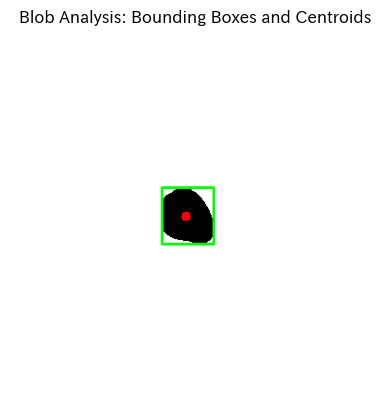

In [15]:
import cv2
# ブロブ領域を描画するためにコピーを作成
image_with_blob_analysis = original_image.copy()
# 外接矩形と重心を描画
for i in range(0, retval):
    if not (1000 < (area := stats[i][4]) < 10000):  # 面積が1000以下または10000以上のブロブは無視
        continue
    
    x, y, w, h, area = stats[i]
    cv2.rectangle(image_with_blob_analysis, (x, y), (x + w, y + h), (0, 255, 0), 2)
    cx, cy = centroids[i]
    cv2.circle(image_with_blob_analysis, (int(cx), int(cy)), 5, (0, 0, 255), -1)
# 画像を表示
plt.imshow(cv2.cvtColor(image_with_blob_analysis, cv2.COLOR_BGR2RGB))
plt.title('Blob Analysis: Bounding Boxes and Centroids')
plt.axis('off')
plt.show()